In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data() #load cifar10 dataset

In [3]:
#normalize the input
X_train = X_train/255.0
X_test = X_test/255.0

Labels: [9]


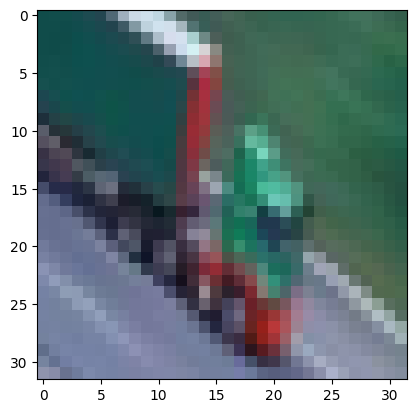

In [4]:
#visualize the data
plt.imshow(X_train[50])
print("Labels:", Y_train[50])

In [5]:
X_train.shape[-1]

3

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomRotation(0.1),
])

In [7]:
def bottleneck_block(X):
    X_skip = X
    c = X.shape[-1]
    #expansion phase, 1x1 convulution to expand
    X = tf.keras.layers.Conv2D(18, (1,1), strides = 1, padding = 'same', use_bias = False)(X)
    X  = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.ReLU(6.0)(X)
    #depthwise 
    X = tf.keras.layers.DepthwiseConv2D((3,3), strides = 1, padding = 'same', use_bias = False)(X)
    X = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.ReLU(6.0)(X)
    #pointwise/projection
    X = tf.keras.layers.Conv2D(c, (1,1), strides = 1, padding = 'same', use_bias = False)(X)
    X = tf.keras.layers.BatchNormalization()(X)
    #skip connection
    X = tf.keras.layers.Add()([X_skip, X])
    return X

In [8]:
def mini_MN():
    X_input = tf.keras.layers.Input(shape= (32,32,3))
    X = data_augmentation(X_input)
    # one convolutional layer
    X = tf.keras.layers.Conv2D(32, (3,3), strides = 1, padding = 'same', use_bias = False)(X_input)
    X = tf.keras.layers.BatchNormalization()(X)
    X = tf.keras.layers.ReLU(max_value=6)(X)
    # a pooling layer?
    X = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(X)
    # x3 bottleneck_blocks
    X = bottleneck_block(X)
    X = bottleneck_block(X)
    X = bottleneck_block(X)
    # global avg pooling layer
    X = tf.keras.layers.GlobalAveragePooling2D()(X)
    #output layer
    X = tf.keras.layers.Dense(10, activation = 'softmax')(X)
    #create model
    model = tf.keras.Model(inputs = X_input, outputs = X)
    return model
    

In [9]:
model = mini_MN()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 15, 15,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 15, 15,    │        576 │ max_pooling2d[0]… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 15, 15,    │        162 │ re_lu_1[0][0]     │
│ (DepthwiseConv2D)   │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │        576 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 15,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 15, 15,    │        576 │ add[0][0]         │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │         72 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 6,080 (23.75 KB)

 Trainable params: 5,608 (21.91 KB)

 Non-trainable params: 472 (1.84 KB)

In [10]:
opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer = opt, loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [11]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=0.00001
)

In [12]:
history = model.fit(
    X_train, Y_train, 
    epochs=20, 
    batch_size = 64, 
    validation_split = 0.2, 
    callbacks=[reduce_lr])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.4179 - loss: 1.6001 - val_accuracy: 0.3535 - val_loss: 1.8588 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.5302 - loss: 1.3108 - val_accuracy: 0.4813 - val_loss: 1.4647 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.5719 - loss: 1.2044 - val_accuracy: 0.4412 - val_loss: 1.5898 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.5942 - loss: 1.1451 - val_accuracy: 0.4481 - val_loss: 1.6841 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.6088 - loss: 1.0992 - val_accuracy: 0.5428 - val_loss: 1.2830 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.6186 - loss: 1.0713 - val_accuracy: 0.5517 - val_loss: 1.2496 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.6

In [13]:
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 3s - 9ms/step - accuracy: 0.6676 - loss: 0.9336

Test accuracy: 0.6675999760627747


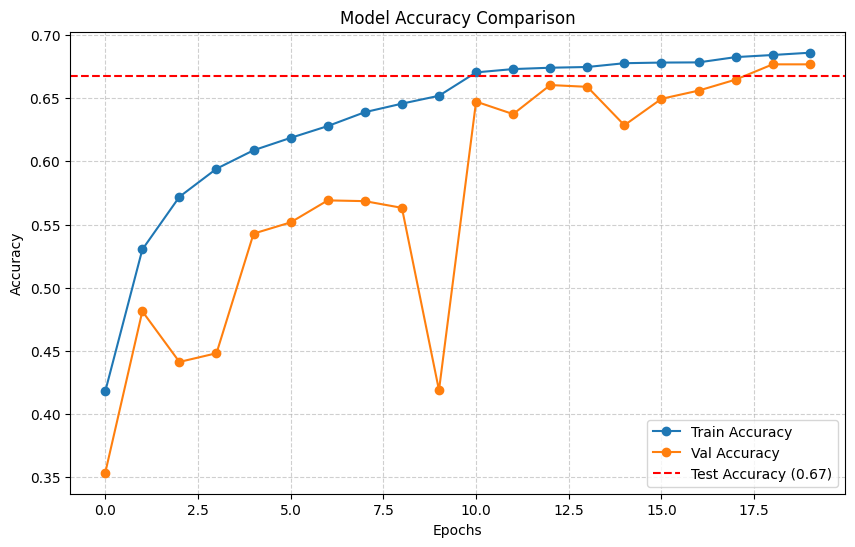

In [14]:
def plot_history(history, test_acc):
    plt.figure(figsize=(10,6))
    #plot training and validation accuracy
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', marker = 'o')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', marker='o')
    #add a horizontal line for test accuracy
    plt.axhline(y=test_acc, color='red', linestyle='--', label=f'Test Accuracy ({test_acc:.2f})')

    plt.title('Model Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function
plot_history(history, test_acc)

In [15]:
model.save('mini_mobilenet_v1_baseline.keras')

In [16]:
preds = model.predict(X_test)
preds = (preds > 0.5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [31]:
trucks_indicies = np.where(Y_test == 2)[0]
print(trucks_indicies)

[  25   35   65   67   70   75   84   86  113  118  123  129  135  138
  147  149  156  160  182  183  195  219  248  249  266  270  291  303
  307  322  340  342  353  354  357  374  384  387  388  391  393  396
  409  424  430  436  448  449  450  497  498  537  548  559  563  564
  569  592  603  618  623  630  655  674  691  692  697  701  706  725
  731  740  748  751  754  755  758  765  775  776  799  813  821  832
  833  837  839  843  846  848  873  877  900  931  933  935  936  972
  980  988 1038 1039 1043 1046 1051 1083 1095 1099 1108 1110 1126 1132
 1146 1148 1150 1151 1172 1196 1202 1240 1248 1251 1254 1257 1277 1278
 1297 1307 1321 1325 1330 1348 1352 1356 1367 1374 1382 1392 1399 1450
 1451 1456 1479 1481 1495 1496 1501 1502 1505 1507 1515 1528 1539 1547
 1567 1575 1581 1587 1610 1623 1644 1656 1673 1678 1690 1709 1723 1746
 1749 1756 1758 1763 1767 1768 1771 1802 1803 1825 1846 1852 1859 1868
 1870 1876 1888 1918 1920 1921 1929 1942 1954 1955 1960 1963 1995 2011
 2033 

In [34]:
preds[65]

array([False, False,  True, False, False, False, False, False, False,
       False])